## Authorship

- **Course / code author:** Xinze Li  
- **Tutorial article:** Xinze Li, Fanfan Lin, Juan J. Rodríguez-Andina, Sergio Vazquez, Homer Alan Mantooth, Leopoldo García Franquelo, "Fundamentals of Artificial Intelligences for Power Electronics," *IEEE Transactions on Industrial Electronics*, 2026.

*These learning resources are still under active refinement; notebooks, data, and documentation may change.*

---



### 10 Physics-Informed Machine Learning for Power Electronics Modeling and Design
  * Artificial Toy Example
    * $a^{2} + b^{2} = c^2$
    * Predicts c given a and b
  * PINN illustrative cases: Temperature annealing equation
    * 1. $T(t) = T_{\infty} + (T_0 - T_{\infty}) e^{-kt}$
    * 2. $\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = \nu \frac{\partial^2 u}{\partial x^2}$  (Burgers' equation)
  * PINN case 2: Fluid and thermal dynamics in a 2-D heat sink
  * Physics-in-architecture neural network - for DAB converters and its variants
    1. PANN inference and training
    2. PANN flexibility - Operating conditions, modulation, circuit parameters, topology
    3. PANN for buck converters

In [1]:
%load_ext autoreload
%autoreload 2

#### 1 Toy Example to Understand Priori Knowledge
* $a^{2} + b^{2} = c^2$
* Task: Predicts c given a and b

##### 1.1 Generate Artificial Dataset

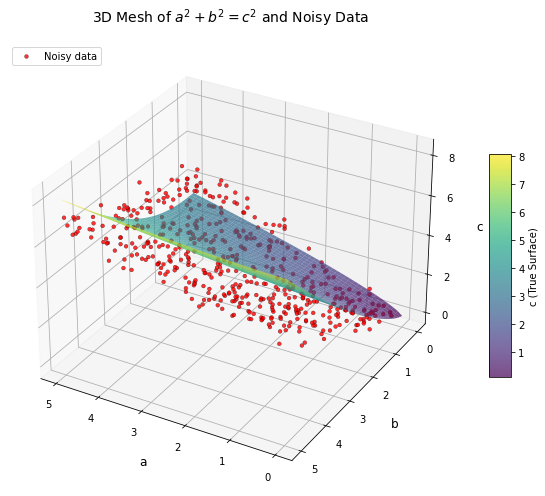

In [2]:
import numpy as np
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

# Number of samples
n_samples = 500

# Generate inputs, a and b, uniformly in [0, 5]
a = np.random.uniform(0, 5, n_samples)
b = np.random.uniform(0, 5, n_samples)

# Compute c from the formula: a^2 + b^2 = c^2 => c = sqrt(a^2 + b^2)
# generate the label c
c = np.sqrt(np.power(a, 2) + np.power(b, 2))

# Add Gaussian noise to a, b, and c
a_noisy = a + np.random.normal(0, 0.25, n_samples)
b_noisy = b + np.random.normal(0, 0.25, n_samples)
c_noisy = c + np.random.normal(0, 0.25, n_samples)

# Optionally, clip to keep within valid range
a_noisy = np.clip(a_noisy, 0, 5)
b_noisy = np.clip(b_noisy, 0, 5)
c_noisy = np.clip(c_noisy, 0, None)  # c should be >= 0

# Create a DataFrame for convenience
df = pd.DataFrame({
    'a': a_noisy,
    'b': b_noisy,
    'c': c_noisy
})

# Show the first few rows
df.head()

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a meshgrid for a and b
a_lin = np.linspace(0, 5, 50)
b_lin = np.linspace(0, 5, 50)
A, B = np.meshgrid(a_lin, b_lin)
C = np.sqrt(np.power(A, 1.5) + np.power(B, 2.5))

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot the mesh surface for the true function
surf = ax.plot_surface(A, B, C, cmap='viridis', alpha=0.7, edgecolor='none', linewidth=0, antialiased=True)

# Plot the noisy data as scatter points
ax.scatter(df['a'], df['b'], df['c'], color='r', s=15, label='Noisy data', alpha=0.8, edgecolor='k', linewidth=0.3)

# Styling
ax.set_xlabel('a', fontsize=12, labelpad=10)
ax.set_ylabel('b', fontsize=12, labelpad=10)
ax.set_zlabel('c', fontsize=12, labelpad=10)
ax.set_title('3D Mesh of $a^{2} + b^{2} = c^2$ and Noisy Data', fontsize=14, pad=20)
ax.view_init(elev=30, azim=120)
fig.colorbar(surf, shrink=0.5, aspect=10, label='c (True Surface)')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()


##### 1.2 Train a Feedforward Neural Network (Classic)

Epoch 50/2000, Train Loss: 0.2643, Val Loss: 0.4136, LR: 0.020000
Epoch 100/2000, Train Loss: 0.1174, Val Loss: 0.2497, LR: 0.020000
Epoch 150/2000, Train Loss: 0.0763, Val Loss: 0.1907, LR: 0.020000
Epoch 200/2000, Train Loss: 0.0623, Val Loss: 0.1718, LR: 0.010000
Epoch 250/2000, Train Loss: 0.0593, Val Loss: 0.1687, LR: 0.010000
Epoch 300/2000, Train Loss: 0.0569, Val Loss: 0.1676, LR: 0.010000
Epoch 350/2000, Train Loss: 0.0542, Val Loss: 0.1660, LR: 0.010000
Epoch 400/2000, Train Loss: 0.0515, Val Loss: 0.1669, LR: 0.005000
Epoch 450/2000, Train Loss: 0.0502, Val Loss: 0.1666, LR: 0.005000
Epoch 500/2000, Train Loss: 0.0492, Val Loss: 0.1674, LR: 0.005000
Epoch 550/2000, Train Loss: 0.0481, Val Loss: 0.1671, LR: 0.005000
Epoch 600/2000, Train Loss: 0.0470, Val Loss: 0.1675, LR: 0.002500
Epoch 650/2000, Train Loss: 0.0464, Val Loss: 0.1678, LR: 0.002500
Epoch 700/2000, Train Loss: 0.0458, Val Loss: 0.1680, LR: 0.002500
Epoch 750/2000, Train Loss: 0.0452, Val Loss: 0.1679, LR: 0.002

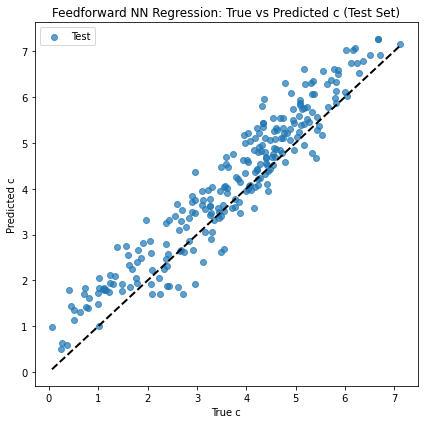

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Prepare data
X = df[['a', 'b']].values.astype(np.float32)
y = df['c'].values.astype(np.float32).reshape(-1, 1)

# Split into train, val, and test sets (e.g., 10% train, 40% val, 50% test)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.8, random_state=42) 

# Standardize features (fit only on train, transform all)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# Do NOT scale y
y_train_scaled = y_train
y_val_scaled = y_val
y_test_scaled = y_test

# Convert to torch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

# Define a feedforward neural network with BatchNorm
class FeedforwardNN(nn.Module):
    def __init__(self):
        super(FeedforwardNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 10),
            nn.BatchNorm1d(10),
            nn.ReLU(),
            nn.Linear(10, 10),
            nn.BatchNorm1d(10),
            nn.ReLU(),
            nn.Linear(10, 1)
        )
    def forward(self, x):
        return self.net(x)

model = FeedforwardNN()

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.02)

# Learning rate scheduler: reduce LR by 50% every 200 epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=200, gamma=0.5)

# Training loop with validation and checkpointing
epochs = 2000
best_val_loss = float('inf')
best_model_state = None

def zscore_weights(module):
    # Z-score (standardize) the weights of all Linear layers in-place
    for m in module.modules():
        if isinstance(m, nn.Linear):
            with torch.no_grad():
                w = m.weight.data
                mean = w.mean()
                std = w.std()
                if std > 0:
                    m.weight.data = (w - mean) / std

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    # Z-score the weights after optimizer step
    zscore_weights(model)
    
    # Step the learning rate scheduler
    scheduler.step()
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_model_state = model.state_dict()  # Save best model weights
    
    if (epoch+1) % 50 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}, LR: {current_lr:.6f}")

# Load best model
model.load_state_dict(best_model_state)

# Evaluate on all datasets
model.eval()
with torch.no_grad():
    # Train set
    y_train_pred = model(X_train_tensor).numpy()
    y_train_true = y_train_tensor.numpy()
    train_mse = np.mean((y_train_pred - y_train_true) ** 2)
    # Validation set
    y_val_pred = model(X_val_tensor).numpy()
    y_val_true = y_val_tensor.numpy()
    val_mse = np.mean((y_val_pred - y_val_true) ** 2)
    # Test set
    y_test_pred = model(X_test_tensor).numpy()
    y_test_true = y_test_tensor.numpy()
    test_mse = np.mean((y_test_pred - y_test_true) ** 2)
    print(f"Train MSE: {train_mse:.4f}")
    print(f"Validation MSE: {val_mse:.4f}")
    print(f"Test MSE: {test_mse:.4f}")

# Optionally, plot predictions vs true values for test set
plt.figure(figsize=(6,6))
plt.scatter(y_test_true, y_test_pred, alpha=0.7, label='Test')
plt.plot([y_test_true.min(), y_test_true.max()], [y_test_true.min(), y_test_true.max()], 'k--', lw=2)
plt.xlabel('True c')
plt.ylabel('Predicted c')
plt.title('Feedforward NN Regression: True vs Predicted c (Test Set)')
plt.tight_layout()
plt.legend()
plt.show()


##### 10.1.3 Train a Feedforward Neural Network with Integrated Physics

Epoch 50/1000, Train Loss: 0.1302 (Data: 0.0949, Phys: 0.3526), Val Loss: 0.6529, Exponent p: 1.9586, LR: 0.050000
Epoch 100/1000, Train Loss: 0.0896 (Data: 0.0727, Phys: 0.1682), Val Loss: 0.2518, Exponent p: 1.9942, LR: 0.050000
Epoch 150/1000, Train Loss: 0.0830 (Data: 0.0713, Phys: 0.1171), Val Loss: 0.2103, Exponent p: 1.9942, LR: 0.050000
Epoch 200/1000, Train Loss: 0.0814 (Data: 0.0712, Phys: 0.1029), Val Loss: 0.2025, Exponent p: 1.9942, LR: 0.050000
Epoch 250/1000, Train Loss: 0.0808 (Data: 0.0707, Phys: 0.1010), Val Loss: 0.2009, Exponent p: 1.9942, LR: 0.050000
Epoch 300/1000, Train Loss: 0.0799 (Data: 0.0705, Phys: 0.0947), Val Loss: 0.1918, Exponent p: 1.9943, LR: 0.050000
Epoch 350/1000, Train Loss: 0.0782 (Data: 0.0692, Phys: 0.0907), Val Loss: 0.1839, Exponent p: 1.9946, LR: 0.050000
Epoch 400/1000, Train Loss: 0.0775 (Data: 0.0685, Phys: 0.0901), Val Loss: 0.1892, Exponent p: 1.9943, LR: 0.025000
Epoch 450/1000, Train Loss: 0.0774 (Data: 0.0684, Phys: 0.0902), Val Loss

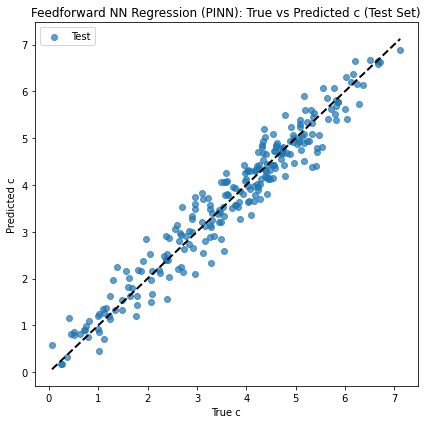

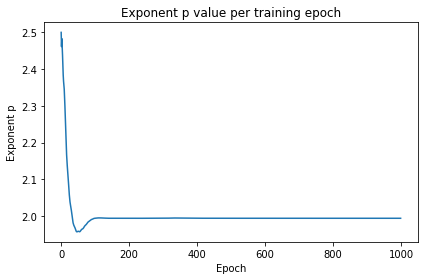

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Prepare data
X = df[['a', 'b']].values.astype(np.float32)
y = df['c'].values.astype(np.float32).reshape(-1, 1)

# Split into train, val, and test sets (e.g., 10% train, 40% val, 50% test)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.8, random_state=42) 

# Standardize features (fit only on train, transform all)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# Do NOT scale y
y_train_scaled = y_train
y_val_scaled = y_val
y_test_scaled = y_test

# Convert to torch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

# Also keep unscaled a, b for physics loss (from original X_train, X_val, X_test)
a_train = torch.tensor(X_train[:, 0], dtype=torch.float32).reshape(-1, 1)
b_train = torch.tensor(X_train[:, 1], dtype=torch.float32).reshape(-1, 1)
a_val = torch.tensor(X_val[:, 0], dtype=torch.float32).reshape(-1, 1)
b_val = torch.tensor(X_val[:, 1], dtype=torch.float32).reshape(-1, 1)
a_test = torch.tensor(X_test[:, 0], dtype=torch.float32).reshape(-1, 1)
b_test = torch.tensor(X_test[:, 1], dtype=torch.float32).reshape(-1, 1)

# Define a feedforward neural network with BatchNorm
class FeedforwardNN(nn.Module):
    def __init__(self):
        super(FeedforwardNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 10),
            nn.BatchNorm1d(10),
            nn.ReLU(),
            nn.Linear(10, 10),
            nn.BatchNorm1d(10),
            nn.ReLU(),
            nn.Linear(10, 1)
        )
    def forward(self, x):
        return self.net(x)

model = FeedforwardNN()

# Make the exponent a trainable parameter, but use softplus and clamp to avoid NaN/Inf gradients
class PhysicsExponent(nn.Module):
    def __init__(self, init_value=1.5):
        super().__init__()
        # Parameterize using unconstrained real value, bias so initial value is correct after softplus+1
        self.raw_exponent = nn.Parameter(torch.log(torch.exp(torch.tensor(float(init_value-1))) - 1))
    def forward(self):
        # Ensure strictly greater than 1 to avoid undefined gradients when c_pred <= 0 or p < 1
        # .softplus + 1 = >1
        exponent = torch.nn.functional.softplus(self.raw_exponent) + 1.0
        # Clamp to reasonable bounds for further safety in pow
        exponent = torch.clamp(exponent, min=1.01, max=10.0)
        return exponent

physics_exponent = PhysicsExponent(init_value=2.5)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(list(model.parameters()) + list(physics_exponent.parameters()), lr=0.05)

# Learning rate scheduler: reduce LR by 50% every 400 epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=400, gamma=0.5)

# Physics-Informed Loss: a^2 + b^2 = c^p, where p is trainable
def physics_loss(a, b, c_pred, p):
    # Avoid negative or zero values for c_pred when raising to fractional p
    # Clamp c_pred >= epsilon
    eps = 1e-5
    c_pred_clamped = torch.clamp(c_pred, min=eps)
    lhs = torch.pow(a, 2) + torch.pow(b, 2)
    rhs = torch.pow(c_pred_clamped, p)
    # To avoid nan gradients, exclude samples where lhs or rhs is nan
    diff = lhs - rhs
    mask = torch.isfinite(diff)
    if not torch.all(mask):
        diff = diff[mask]
    return torch.mean(diff ** 2)

# Z-score (standardize) the weights of all Linear layers in-place
def zscore_weights(module):
    for m in module.modules():
        if isinstance(m, nn.Linear):
            with torch.no_grad():
                w = m.weight.data
                mean = w.mean()
                std = w.std()
                if std > 0:
                    m.weight.data = (w - mean) / std

# Training loop with validation and checkpointing
epochs = 1000
best_val_loss = float('inf')
best_model_state = None
best_exponent_state = None

lambda_phys = 0.1  # Weight for physics loss, can be tuned

# Add: record p (exponent) value at each epoch
p_history = []

for epoch in range(epochs):
    # Record current value of exponent p
    p_history.append(physics_exponent().item())

    model.train()
    physics_exponent.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    # Data loss
    data_loss = criterion(outputs, y_train_tensor)
    # Physics loss (use unscaled a, b, and predicted c, and trainable exponent)
    p = physics_exponent()
    phys_loss = physics_loss(a_train, b_train, outputs, p)
    # Total loss
    loss = data_loss + lambda_phys * phys_loss
    loss.backward()
    # Gradient clipping for safety
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
    for param in physics_exponent.parameters():
        if param.grad is not None:
            param.grad.data = torch.nan_to_num(param.grad.data, nan=0.0, posinf=1.0, neginf=-1.0)
    optimizer.step()

    # Z-score the weights after optimizer step
    zscore_weights(model)

    # Step the learning rate scheduler
    scheduler.step()
    
    # Validation
    model.eval()
    physics_exponent.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_p = physics_exponent()
        val_data_loss = criterion(val_outputs, y_val_tensor)
        val_phys_loss = physics_loss(a_val, b_val, val_outputs, val_p)
        val_loss = val_data_loss + lambda_phys * val_phys_loss
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_model_state = model.state_dict()  # Save best model weights
        best_exponent_state = physics_exponent.state_dict()  # Save best exponent
    
    if (epoch+1) % 50 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {loss.item():.4f} (Data: {data_loss.item():.4f}, Phys: {phys_loss.item():.4f}), Val Loss: {val_loss.item():.4f}, Exponent p: {p.item():.4f}, LR: {current_lr:.6f}")

# Load best model and exponent
model.load_state_dict(best_model_state)
physics_exponent.load_state_dict(best_exponent_state)

# Evaluate on all datasets
model.eval()
physics_exponent.eval()
with torch.no_grad():
    # Train set
    y_train_pred = model(X_train_tensor).numpy()
    y_train_true = y_train_tensor.numpy()
    train_mse = np.mean((y_train_pred - y_train_true) ** 2)
    # Validation set
    y_val_pred = model(X_val_tensor).numpy()
    y_val_true = y_val_tensor.numpy()
    val_mse = np.mean((y_val_pred - y_val_true) ** 2)
    # Test set
    y_test_pred = model(X_test_tensor).numpy()
    y_test_true = y_test_tensor.numpy()
    test_mse = np.mean((y_test_pred - y_test_true) ** 2)
    print(f"Train MSE: {train_mse:.4f}")
    print(f"Validation MSE: {val_mse:.4f}")
    print(f"Test MSE: {test_mse:.4f}")
    print(f"Learned exponent p: {physics_exponent().item():.4f}")

# Optionally, plot predictions vs true values for test set
plt.figure(figsize=(6,6))
plt.scatter(y_test_true, y_test_pred, alpha=0.7, label='Test')
plt.plot([y_test_true.min(), y_test_true.max()], [y_test_true.min(), y_test_true.max()], 'k--', lw=2)
plt.xlabel('True c')
plt.ylabel('Predicted c')
plt.title('Feedforward NN Regression (PINN): True vs Predicted c (Test Set)')
plt.tight_layout()
plt.legend()
plt.show()

# (Optional) Plot the evolution of exponent p during training
plt.figure()
plt.plot(p_history)
plt.xlabel("Epoch")
plt.ylabel("Exponent p")
plt.title("Exponent p value per training epoch")
plt.tight_layout()
plt.show()


##### 10.1.4 Prior in Architecture

Epoch 5/500  Train Loss: 0.82739  Val Loss: 0.65848  p: 2.3484
Epoch 10/500  Train Loss: 0.33053  Val Loss: 0.25404  p: 2.1726
Epoch 15/500  Train Loss: 0.09706  Val Loss: 0.13285  p: 2.0237
Epoch 20/500  Train Loss: 0.14106  Val Loss: 0.22996  p: 1.9296
Epoch 25/500  Train Loss: 0.16903  Val Loss: 0.23084  p: 1.9148
Epoch 30/500  Train Loss: 0.10757  Val Loss: 0.15421  p: 1.9556
Epoch 35/500  Train Loss: 0.09048  Val Loss: 0.13081  p: 2.0062
Epoch 40/500  Train Loss: 0.10246  Val Loss: 0.13451  p: 2.0325
Epoch 45/500  Train Loss: 0.09901  Val Loss: 0.13168  p: 2.0271
Epoch 50/500  Train Loss: 0.09016  Val Loss: 0.13271  p: 2.0045
Epoch 55/500  Train Loss: 0.09063  Val Loss: 0.14039  p: 1.9851
Epoch 60/500  Train Loss: 0.09175  Val Loss: 0.14094  p: 1.9810
Epoch 65/500  Train Loss: 0.08979  Val Loss: 0.13550  p: 1.9897
Epoch 70/500  Train Loss: 0.08955  Val Loss: 0.13236  p: 1.9998
Epoch 75/500  Train Loss: 0.08990  Val Loss: 0.13203  p: 2.0029
Epoch 80/500  Train Loss: 0.08950  Val Lo

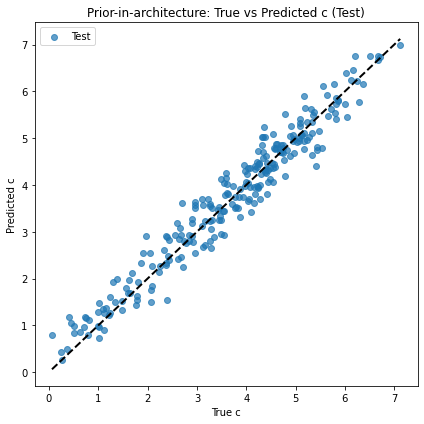

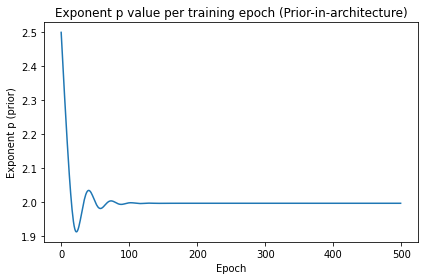

In [23]:
# Prior-in-architecture: Model is strictly a^2 + b^2 = c^p, fit p by data, only trainable parameter is p

import torch
import torch.nn as nn
import torch.optim as optim

class EqExponent(nn.Module):
    def __init__(self, init_value=2.0):
        super().__init__()
        # Raw parameter for exponent p, enforced p > 1 (via softplus + 1)
        self.raw_p = nn.Parameter(torch.log(torch.exp(torch.tensor(float(init_value-1))) - 1))
    def forward(self, a, b):
        # Returns c = (a^2 + b^2)^{1/p}
        # Ensure p > 1, clamp for numerical safety
        p = torch.nn.functional.softplus(self.raw_p) + 1.0
        p = torch.clamp(p, min=1.01, max=10.0)
        # Compute c_pred = (a^2 + b^2)^{1/p} elementwise
        sumsq = torch.pow(a, 2) + torch.pow(b, 2)
        # Clamp sumsq for positive roots, to avoid nan for tiny a/b
        sumsq = torch.clamp(sumsq, min=1e-6)
        return torch.pow(sumsq, 1.0/p), p

# Prepare data: use original (unscaled) a, b and y = c (already torch tensors)
X_full = torch.tensor(df[['a', 'b']].values.astype('float32'))
y_full = torch.tensor(df['c'].values.astype('float32').reshape(-1, 1))
a_all = X_full[:, 0:1]
b_all = X_full[:, 1:2]
c_true = y_full

# Split into train/val/test sets (same split as previous)
from sklearn.model_selection import train_test_split
idx = torch.arange(a_all.shape[0])
idx_temp, idx_test = train_test_split(idx, test_size=0.5, random_state=42)
idx_train, idx_val = train_test_split(idx_temp, test_size=0.8, random_state=42)

a_train, b_train, c_train = a_all[idx_train], b_all[idx_train], c_true[idx_train]
a_val, b_val, c_val = a_all[idx_val], b_all[idx_val], c_true[idx_val]
a_test, b_test, c_test = a_all[idx_test], b_all[idx_test], c_true[idx_test]

# Model, loss, optimizer
prior_model = EqExponent(init_value=2.5)
mse_criterion = nn.MSELoss()
optimizer = optim.Adam(prior_model.parameters(), lr=0.05)

epochs = 500
best_val_loss = float('inf')
best_state = None

# Save p value at every epoch
p_history_prior = []

for epoch in range(epochs):
    prior_model.train()
    optimizer.zero_grad()
    c_pred_train, p = prior_model(a_train, b_train)
    train_loss = mse_criterion(c_pred_train, c_train)
    train_loss.backward()
    optimizer.step()

    # Save exponent p at this epoch
    p_history_prior.append(p.item())
    
    # Validation
    prior_model.eval()
    with torch.no_grad():
        c_pred_val, p_val = prior_model(a_val, b_val)
        val_loss = mse_criterion(c_pred_val, c_val)
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_state = prior_model.state_dict()
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs}  Train Loss: {train_loss.item():.5f}  Val Loss: {val_loss.item():.5f}  p: {p.item():.4f}")

# Load best
prior_model.load_state_dict(best_state)

# Evaluate on all sets
prior_model.eval()
with torch.no_grad():
    c_pred_train, p_train = prior_model(a_train, b_train)
    c_pred_val, p_val = prior_model(a_val, b_val)
    c_pred_test, p_test = prior_model(a_test, b_test)
    train_mse = mse_criterion(c_pred_train, c_train).item()
    val_mse = mse_criterion(c_pred_val, c_val).item()
    test_mse = mse_criterion(c_pred_test, c_test).item()
    print(f"(Prior Model) Train MSE: {train_mse:.4f}")
    print(f"(Prior Model) Val MSE: {val_mse:.4f}")
    print(f"(Prior Model) Test MSE: {test_mse:.4f}")
    print(f"Learned exponent p: {p_train.item():.4f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(c_test.numpy(), c_pred_test.numpy(), alpha=0.7, label='Test')
plt.plot([c_test.min(), c_test.max()], [c_test.min(), c_test.max()], 'k--', lw=2)
plt.xlabel('True c')
plt.ylabel('Predicted c')
plt.title('Prior-in-architecture: True vs Predicted c (Test)')
plt.tight_layout()
plt.legend()
plt.show()

# (Optional) Plot the evolution of exponent p for prior-in-architecture model
plt.figure()
plt.plot(p_history_prior)
plt.xlabel("Epoch")
plt.ylabel("Exponent p (prior)")
plt.title("Exponent p value per training epoch (Prior-in-architecture)")
plt.tight_layout()
plt.show()

In [27]:
import numpy as np
import pandas as pd

# Make sure p_history and p_history_prior exist prior to this cell

# Save both p_history and p_history_prior into a csv
# They may have different lengths, so use a DataFrame for alignment

p_df = pd.DataFrame({
    "p_history": pd.Series(p_history),
    "p_history_prior": pd.Series(p_history_prior)
})
p_df.to_csv("p_history_and_prior.csv", index_label="epoch")

##### 10.1.5 Train a Feedforward Neural Network with Wrong Integrated Physics

Epoch 50/4000, Train Loss: 8.6293 (Data: 4.9741, Phys: 36.5525), Val Loss: 107.6463, Exponent p: 2.3855, LR: 0.050000
Epoch 100/4000, Train Loss: 6.2512 (Data: 5.2273, Phys: 10.2394), Val Loss: 12.7154, Exponent p: 2.3904, LR: 0.050000
Epoch 150/4000, Train Loss: 5.0903 (Data: 4.5730, Phys: 5.1728), Val Loss: 19.1046, Exponent p: 2.4133, LR: 0.050000
Epoch 200/4000, Train Loss: 5.1510 (Data: 4.7162, Phys: 4.3483), Val Loss: 8.9256, Exponent p: 2.4151, LR: 0.050000
Epoch 250/4000, Train Loss: 4.9280 (Data: 4.5468, Phys: 3.8120), Val Loss: 8.5747, Exponent p: 2.4136, LR: 0.050000
Epoch 300/4000, Train Loss: 5.1567 (Data: 4.7863, Phys: 3.7039), Val Loss: 8.8775, Exponent p: 2.4109, LR: 0.050000
Epoch 350/4000, Train Loss: 5.0330 (Data: 4.6974, Phys: 3.3560), Val Loss: 10.1304, Exponent p: 2.4060, LR: 0.050000
Epoch 400/4000, Train Loss: 5.4016 (Data: 4.7990, Phys: 6.0260), Val Loss: 10.4543, Exponent p: 2.4082, LR: 0.025000
Epoch 450/4000, Train Loss: 4.4616 (Data: 4.2440, Phys: 2.1762), 

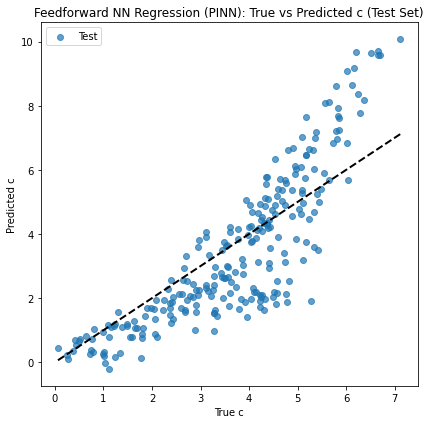

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Prepare data
X = df[['a', 'b']].values.astype(np.float32)
y = df['c'].values.astype(np.float32).reshape(-1, 1)

# Split into train, val, and test sets (e.g., 10% train, 40% val, 50% test)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.8, random_state=42) 

# Standardize features (fit only on train, transform all)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# Do NOT scale y
y_train_scaled = y_train
y_val_scaled = y_val
y_test_scaled = y_test

# Convert to torch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

# Also keep unscaled a, b for physics loss (from original X_train, X_val, X_test)
a_train = torch.tensor(X_train[:, 0], dtype=torch.float32).reshape(-1, 1)
b_train = torch.tensor(X_train[:, 1], dtype=torch.float32).reshape(-1, 1)
a_val = torch.tensor(X_val[:, 0], dtype=torch.float32).reshape(-1, 1)
b_val = torch.tensor(X_val[:, 1], dtype=torch.float32).reshape(-1, 1)
a_test = torch.tensor(X_test[:, 0], dtype=torch.float32).reshape(-1, 1)
b_test = torch.tensor(X_test[:, 1], dtype=torch.float32).reshape(-1, 1)

# Define a feedforward neural network with BatchNorm
class FeedforwardNN(nn.Module):
    def __init__(self):
        super(FeedforwardNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 10),
            nn.BatchNorm1d(10),
            nn.ReLU(),
            nn.Linear(10, 10),
            nn.BatchNorm1d(10),
            nn.ReLU(),
            nn.Linear(10, 1)
        )
    def forward(self, x):
        return self.net(x)

model = FeedforwardNN()

# Make the exponent of a a trainable parameter with NaN/Inf safety
class PhysicsExponent(nn.Module):
    def __init__(self, init_value=1.5):
        super().__init__()
        # Use unconstrained raw exponent, but parametrize and clamp final output
        self.raw_exponent = nn.Parameter(torch.log(torch.exp(torch.tensor(float(init_value-1))) - 1))
    def forward(self):
        # strictly >1, and clamp to avoid very high values for pow, for safety
        exponent = torch.nn.functional.softplus(self.raw_exponent) + 1.0
        exponent = torch.clamp(exponent, min=1.01, max=10.0)
        return exponent

physics_exponent = PhysicsExponent(init_value=2.5)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(list(model.parameters()) + list(physics_exponent.parameters()), lr=0.05)

# Learning rate scheduler: reduce LR by 50% every 400 epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=400, gamma=0.5)

# Physics-Informed Loss with clamping for computational safety (NaN-prevention)
def physics_loss(a, b, c_pred, p):
    # purposely wrong physics, but implement NaN safety
    # Clamp c_pred to positive values to prevent nan gradient/power issues (especially at low p)
    eps = 1e-5
    c_pred_clamped = torch.clamp(c_pred, min=eps)
    # Clamp inputs similarly for lhs
    a_clamped = torch.clamp(a, min=eps)
    b_clamped = torch.clamp(b, min=eps)
    lhs = torch.pow(a_clamped, 2) * torch.pow(b_clamped, 2)
    rhs = torch.pow(c_pred_clamped, p)
    diff = lhs - rhs
    # Only accumulate finite (non-nan, non-inf) terms
    mask = torch.isfinite(diff)
    if not torch.all(mask):
        diff = diff[mask]
    return torch.mean(diff ** 2)

# Z-score (standardize) the weights of all Linear layers in-place
def zscore_weights(module):
    for m in module.modules():
        if isinstance(m, nn.Linear):
            with torch.no_grad():
                w = m.weight.data
                mean = w.mean()
                std = w.std()
                if std > 0:
                    m.weight.data = (w - mean) / std

# Training loop with validation and checkpointing
epochs = 4000
best_val_loss = float('inf')
best_model_state = None
best_exponent_state = None

lambda_phys = 0.1  # Weight for physics loss, can be tuned

for epoch in range(epochs):
    model.train()
    physics_exponent.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    # Data loss
    data_loss = criterion(outputs, y_train_tensor)
    # Physics loss (use unscaled a, b, and predicted c, and trainable exponent)
    p = physics_exponent()
    phys_loss = physics_loss(a_train, b_train, outputs, p)
    # Total loss
    loss = data_loss + lambda_phys * phys_loss
    loss.backward()
    # Safety: clip gradients of model and exponent to avoid Inf/nan update
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
    for param in physics_exponent.parameters():
        if param.grad is not None:
            param.grad.data = torch.nan_to_num(param.grad.data, nan=0.0, posinf=1.0, neginf=-1.0)
    optimizer.step()

    # Z-score the weights after optimizer step
    zscore_weights(model)

    # Step the learning rate scheduler
    scheduler.step()
    
    # Validation
    model.eval()
    physics_exponent.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_p = physics_exponent()
        val_data_loss = criterion(val_outputs, y_val_tensor)
        val_phys_loss = physics_loss(a_val, b_val, val_outputs, val_p)
        val_loss = val_data_loss + lambda_phys * val_phys_loss
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_model_state = model.state_dict()  # Save best model weights
        best_exponent_state = physics_exponent.state_dict()  # Save best exponent
    
    if (epoch+1) % 50 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {loss.item():.4f} (Data: {data_loss.item():.4f}, Phys: {phys_loss.item():.4f}), Val Loss: {val_loss.item():.4f}, Exponent p: {p.item():.4f}, LR: {current_lr:.6f}")

# Load best model and exponent (safety: check vs None before loading)
if best_model_state is not None and best_exponent_state is not None:
    model.load_state_dict(best_model_state)
    physics_exponent.load_state_dict(best_exponent_state)
else:
    print("Warning: No best state recorded, model may not have converged.")

# Evaluate on all datasets
model.eval()
physics_exponent.eval()
with torch.no_grad():
    # Train set
    y_train_pred = model(X_train_tensor).numpy()
    y_train_true = y_train_tensor.numpy()
    train_mse = np.mean((y_train_pred - y_train_true) ** 2)
    # Validation set
    y_val_pred = model(X_val_tensor).numpy()
    y_val_true = y_val_tensor.numpy()
    val_mse = np.mean((y_val_pred - y_val_true) ** 2)
    # Test set
    y_test_pred = model(X_test_tensor).numpy()
    y_test_true = y_test_tensor.numpy()
    test_mse = np.mean((y_test_pred - y_test_true) ** 2)
    print(f"Train MSE: {train_mse:.4f}")
    print(f"Validation MSE: {val_mse:.4f}")
    print(f"Test MSE: {test_mse:.4f}")
    print(f"Learned exponent p: {physics_exponent().item():.4f}")

# Optionally, plot predictions vs true values for test set
plt.figure(figsize=(6,6))
plt.scatter(y_test_true, y_test_pred, alpha=0.7, label='Test')
plt.plot([y_test_true.min(), y_test_true.max()], [y_test_true.min(), y_test_true.max()], 'k--', lw=2)
plt.xlabel('True c')
plt.ylabel('Predicted c')
plt.title('Feedforward NN Regression (PINN): True vs Predicted c (Test Set)')
plt.tight_layout()
plt.legend()
plt.show()
